In [1]:
# ============================================================
# CELL 1 — KAGGLE INPUT DISCOVERY
# ============================================================

from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

print("=" * 80)
print("KAGGLE INPUT DATASETS")
print("=" * 80)

for p in sorted(KAGGLE_INPUT.iterdir()):
    print(p)

KAGGLE INPUT DATASETS
/kaggle/input/datasets


In [2]:
# ============================================================
# CELL 2 — FIND PREPARED DDR DATASET
# ============================================================

from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

DDR_ROOT = None

# Search for an already-extracted DDR structure
for candidate in INPUT_ROOT.rglob("ddr"):
    if (
        (candidate / "train").exists()
        and (candidate / "val").exists()
        and (candidate / "test").exists()
    ):
        DDR_ROOT = candidate
        break

# Also search one level deeper if Kaggle uploaded the folder
if DDR_ROOT is None:
    for candidate in INPUT_ROOT.rglob("*"):
        if candidate.is_dir():
            if (
                (candidate / "train").exists()
                and (candidate / "val").exists()
                and (candidate / "test").exists()
            ):
                DDR_ROOT = candidate
                break

if DDR_ROOT is None:
    raise FileNotFoundError(
        "Prepared DDR dataset was not found under /kaggle/input.\n"
        "Attach your DDR Kaggle Dataset using Add Input."
    )

print("=" * 80)
print("PREPARED DDR DATASET FOUND")
print("=" * 80)
print("DDR_ROOT:")
print(DDR_ROOT)

PREPARED DDR DATASET FOUND
DDR_ROOT:
/kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr


In [3]:
# ============================================================
# CELL 3 — DDR DATASET VERIFICATION
# ============================================================

from pathlib import Path

EXPECTED_CLASSES = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative_DR",
}

SPLITS = ["train", "val", "test"]

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

print("=" * 80)
print("DDR DATASET VERIFICATION")
print("=" * 80)

total = 0

for split in SPLITS:

    split_dir = DDR_ROOT / split

    if not split_dir.exists():
        raise FileNotFoundError(
            f"Missing split directory: {split_dir}"
        )

    split_total = 0

    print(f"\n{split.upper()}")

    for label, class_name in EXPECTED_CLASSES.items():

        possible_dirs = [
            split_dir / f"{label}_{class_name}",
            split_dir / class_name,
        ]

        class_dir = next(
            (d for d in possible_dirs if d.exists()),
            None
        )

        if class_dir is None:
            raise FileNotFoundError(
                f"Missing class directory for {split}: {class_name}"
            )

        images = [
            p for p in class_dir.rglob("*")
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        count = len(images)

        print(
            f"  {label} - {class_name:18s}: {count:6,}"
        )

        split_total += count

    print(f"  {'TOTAL':22s}: {split_total:6,}")

    total += split_total

print("\n" + "=" * 80)
print(f"TOTAL DDR IMAGES: {total:,}")
print("=" * 80)

DDR DATASET VERIFICATION

TRAIN
  0 - No_DR             :  4,933
  1 - Mild              :    504
  2 - Moderate          :  3,581
  3 - Severe            :    189
  4 - Proliferative_DR  :    730
  TOTAL                 :  9,937

VAL
  0 - No_DR             :    616
  1 - Mild              :     63
  2 - Moderate          :    448
  3 - Severe            :     24
  4 - Proliferative_DR  :     91
  TOTAL                 :  1,242

TEST
  0 - No_DR             :    617
  1 - Mild              :     63
  2 - Moderate          :    448
  3 - Severe            :     23
  4 - Proliferative_DR  :     92
  TOTAL                 :  1,243

TOTAL DDR IMAGES: 12,422


In [4]:
# ============================================================
# CELL 4 — PATH CONFIGURATION
# ============================================================

TRAIN_DIR = DDR_ROOT / "train"
VAL_DIR   = DDR_ROOT / "val"
TEST_DIR  = DDR_ROOT / "test"

METADATA_DIR = DDR_ROOT / "metadata"

print("TRAIN :", TRAIN_DIR)
print("VAL   :", VAL_DIR)
print("TEST  :", TEST_DIR)
print("META  :", METADATA_DIR)

TRAIN : /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/train
VAL   : /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/val
TEST  : /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/test
META  : /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/metadata


In [5]:
# ============================================================
# CELL 5 — GPU CHECK
# ============================================================

import torch

print("=" * 80)
print("DEVICE CHECK")
print("=" * 80)

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )
    DEVICE = torch.device("cuda")
else:
    print("WARNING: CUDA unavailable. Training will use CPU.")
    DEVICE = torch.device("cpu")

print("Selected device:", DEVICE)

DEVICE CHECK
PyTorch version: 2.11.0+cu128
CUDA available : True
GPU: Tesla T4
GPU memory: 14.56 GB
Selected device: cuda


In [6]:
# ============================================================
# CELL 1 — PACKAGE CHECK
# ============================================================

import sys
import subprocess
import importlib.util

required = {
    "torch": "torch",
    "torchvision": "torchvision",
    "numpy": "numpy",
    "pandas": "pandas",
    "PIL": "pillow",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
}

missing = [
    package
    for module, package in required.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Installing:", missing)
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *missing
    ])

print("Package check complete.")

Package check complete.


In [7]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import json
import time
import math
import random
import shutil
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, WeightedRandomSampler

import torchvision
from torchvision import datasets, transforms
from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    cohen_kappa_score,
    matthews_corrcoef,
    log_loss,
    roc_curve,
    precision_recall_curve,
    auc,
    brier_score_loss
)

from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128


In [8]:
# ============================================================
# CELL 3 — EXPERIMENT CONFIGURATION
# ============================================================

SEED = 42

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

# Automatically locate prepared DDR dataset
INPUT_ROOT = Path("/kaggle/input")

DDR_ROOT = None

for candidate in INPUT_ROOT.rglob("*"):
    if not candidate.is_dir():
        continue

    if (
        (candidate / "train").exists()
        and (candidate / "val").exists()
        and (candidate / "test").exists()
    ):
        DDR_ROOT = candidate
        break

if DDR_ROOT is None:
    raise FileNotFoundError(
        "Prepared DDR dataset was not found in /kaggle/input."
    )

TRAIN_DIR = DDR_ROOT / "train"
VAL_DIR   = DDR_ROOT / "val"
TEST_DIR  = DDR_ROOT / "test"

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

OUTPUT_ROOT = Path("/kaggle/working/mobilenetv2_ddr_results")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
PLOT_DIR       = OUTPUT_ROOT / "plots"
METRIC_DIR     = OUTPUT_ROOT / "metrics"
GRADCAM_DIR    = OUTPUT_ROOT / "gradcam"

for d in [
    CHECKPOINT_DIR,
    PLOT_DIR,
    METRIC_DIR,
    GRADCAM_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Classes
# ------------------------------------------------------------

CLASS_NAMES = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]

NUM_CLASSES = len(CLASS_NAMES)

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50

NUM_WORKERS = 2

# Training-only random oversampling
USE_OVERSAMPLING = True

# ------------------------------------------------------------
# Optimization
# ------------------------------------------------------------

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4

OPTIMIZER_NAME = "AdamW"

# Scheduler
USE_SCHEDULER = True
SCHEDULER_NAME = "ReduceLROnPlateau"

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 3
MIN_LR = 1e-7

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

USE_EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 10

# ------------------------------------------------------------
# Checkpoint selection
# ------------------------------------------------------------

CHECKPOINT_METRIC = "f1_macro"

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("MOBILENETV2 — DDR CONFIGURATION")
print("=" * 80)

print("DDR root :", DDR_ROOT)
print("Train    :", TRAIN_DIR)
print("Val      :", VAL_DIR)
print("Test     :", TEST_DIR)

print()
print("Image size :", IMAGE_SIZE)
print("Batch size :", BATCH_SIZE)
print("Epochs     :", EPOCHS)
print("Workers    :", NUM_WORKERS)

print()
print("Oversampling:", USE_OVERSAMPLING)

print()
print("Optimizer:", OPTIMIZER_NAME)
print("LR:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

print()
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

MOBILENETV2 — DDR CONFIGURATION
DDR root : /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr
Train    : /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/train
Val      : /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/val
Test     : /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/test

Image size : 224
Batch size : 16
Epochs     : 50
Workers    : 2

Oversampling: True

Optimizer: AdamW
LR: 0.0001
Weight decay: 0.0005

Device: cuda
GPU: Tesla T4


In [9]:
# ============================================================
# CELL 4 — REPRODUCIBILITY
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print("Seed:", SEED)

Seed: 42


In [10]:
# ============================================================
# CELL 5 — DATASET VERIFICATION
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

print("=" * 80)
print("DDR DATASET VERIFICATION")
print("=" * 80)

dataset_counts = {}

for split_name, split_dir in [
    ("train", TRAIN_DIR),
    ("val", VAL_DIR),
    ("test", TEST_DIR)
]:

    ds = datasets.ImageFolder(split_dir)

    print(f"\n{split_name.upper()}")

    print("Classes:", ds.classes)

    counts = Counter(ds.targets)

    total = len(ds)

    dataset_counts[split_name] = counts

    for idx, class_name in enumerate(ds.classes):
        print(
            f"{idx}: "
            f"{class_name:20s} "
            f"{counts[idx]:6,}"
        )

    print(f"TOTAL: {total:,}")

DDR DATASET VERIFICATION

TRAIN
Classes: ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']
0: 0_No_DR               4,933
1: 1_Mild                  504
2: 2_Moderate            3,581
3: 3_Severe                189
4: 4_Proliferative_DR      730
TOTAL: 9,937

VAL
Classes: ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']
0: 0_No_DR                 616
1: 1_Mild                   63
2: 2_Moderate              448
3: 3_Severe                 24
4: 4_Proliferative_DR       91
TOTAL: 1,242

TEST
Classes: ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']
0: 0_No_DR                 617
1: 1_Mild                   63
2: 2_Moderate              448
3: 3_Severe                 23
4: 4_Proliferative_DR       92
TOTAL: 1,243


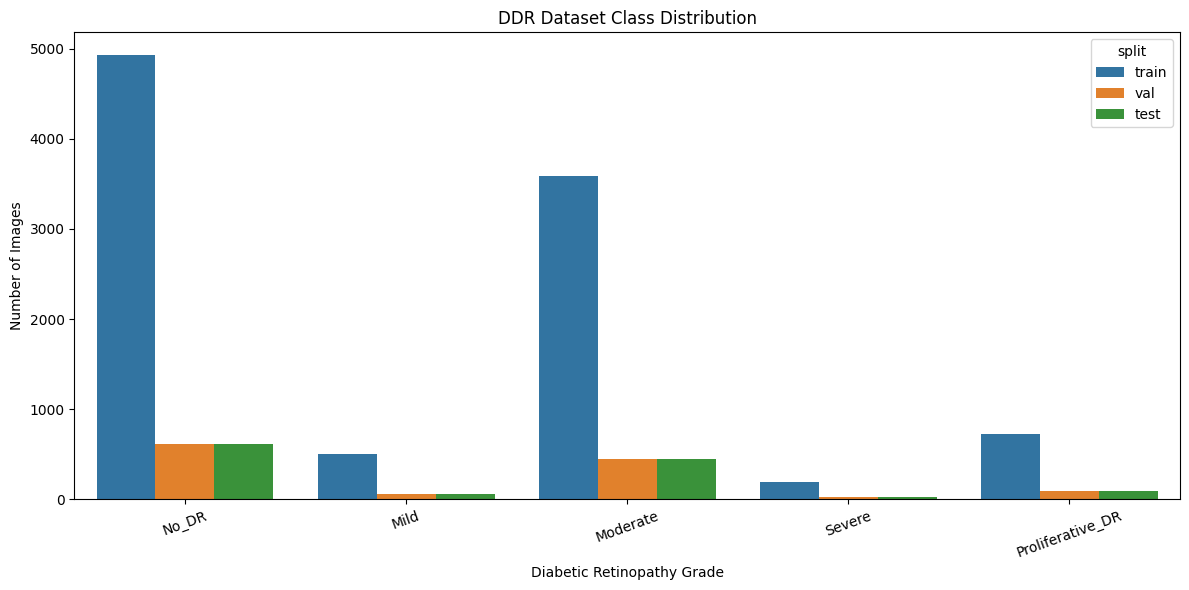

In [11]:
# ============================================================
# CELL 6 — CLASS DISTRIBUTION
# ============================================================

rows = []

for split, counts in dataset_counts.items():
    for idx, class_name in enumerate(CLASS_NAMES):
        rows.append({
            "split": split,
            "class": class_name,
            "count": counts[idx]
        })

distribution_df = pd.DataFrame(rows)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=distribution_df,
    x="class",
    y="count",
    hue="split"
)

plt.title("DDR Dataset Class Distribution")
plt.xlabel("Diabetic Retinopathy Grade")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "dataset_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ============================================================
# CELL 7 — IMAGE TRANSFORMS
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomRotation(
        degrees=40
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.20, 0.20),
        shear=0.20,
        scale=(0.80, 1.20)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Transforms created.")

Transforms created.


In [13]:
# ============================================================
# CELL 8 — CREATE DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

print()
print("Class mapping:")
print(train_dataset.class_to_idx)

Train: 9937
Val  : 1242
Test : 1243

Class mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}


In [14]:
# ============================================================
# CELL 9 — TRAINING-ONLY OVERSAMPLING
# ============================================================

train_targets = np.array(
    train_dataset.targets
)

class_counts = np.bincount(
    train_targets,
    minlength=NUM_CLASSES
)

print("Original training counts:")
for i, name in enumerate(CLASS_NAMES):
    print(
        f"{i} {name:20s}: "
        f"{class_counts[i]:,}"
    )

if USE_OVERSAMPLING:

    class_weights = (
        1.0 / class_counts
    )

    sample_weights = class_weights[
        train_targets
    ]

    sample_weights = torch.as_tensor(
        sample_weights,
        dtype=torch.double
    )

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_dataset),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0)
    )

    print("\nTraining oversampling: ENABLED")

else:

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0)
    )

    print("\nTraining oversampling: DISABLED")


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

print()
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Original training counts:
0 No_DR               : 4,933
1 Mild                : 504
2 Moderate            : 3,581
3 Severe              : 189
4 Proliferative_DR    : 730

Training oversampling: ENABLED

Train batches: 622
Val batches  : 78
Test batches : 78


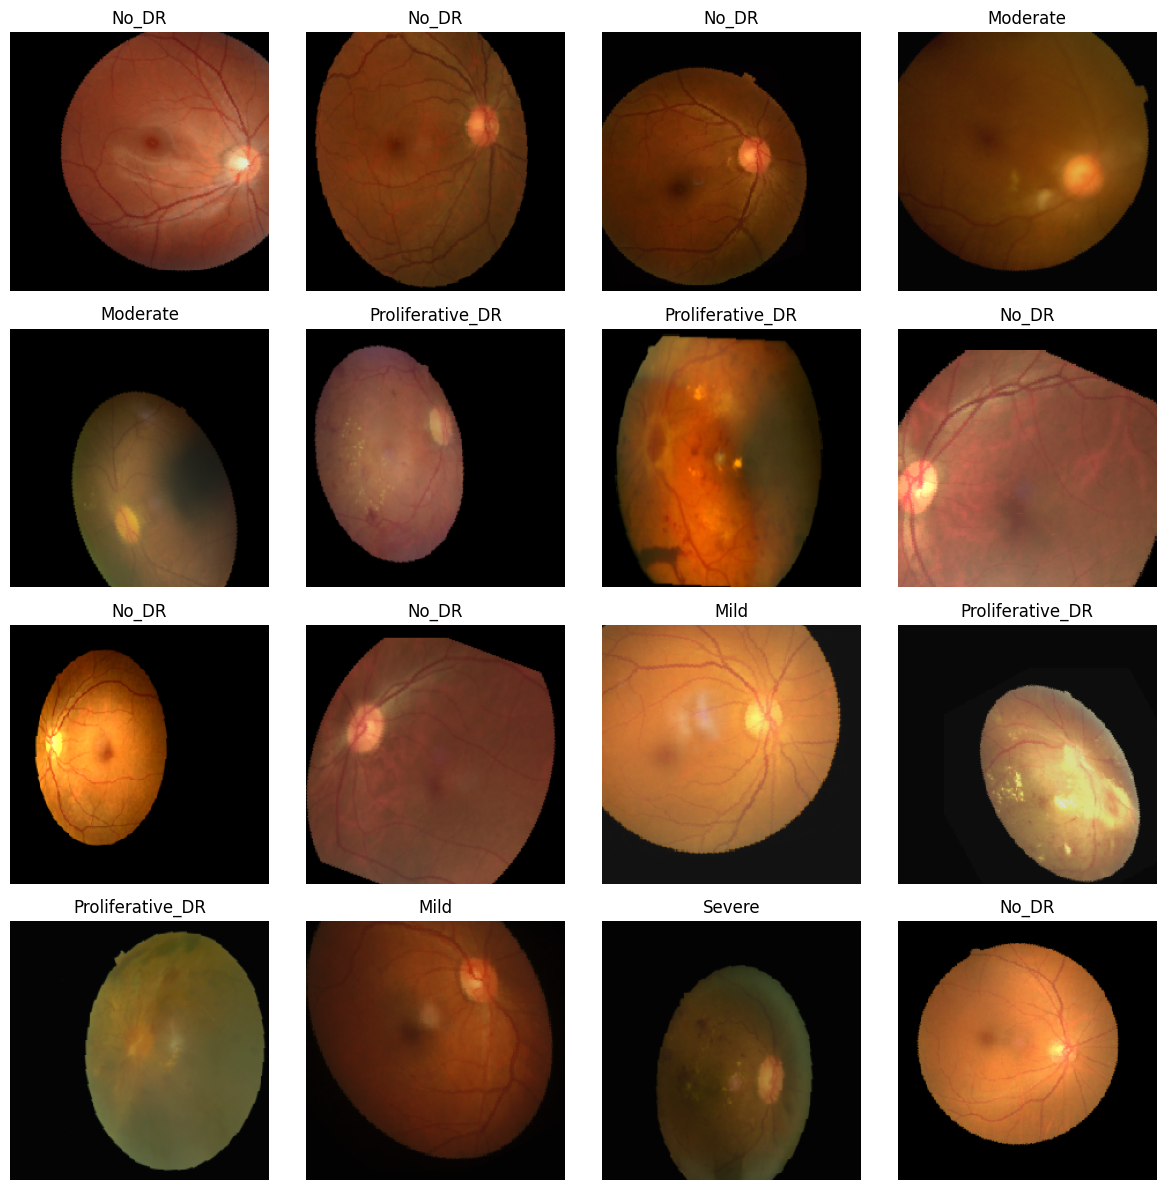

In [15]:
# ============================================================
# CELL 10 — SAMPLE TRAINING IMAGES
# ============================================================

def denormalize(tensor):
    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    return tensor * std + mean


images, labels = next(iter(train_loader))

n = min(16, len(images))

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

axes = axes.flatten()

for i in range(n):

    img = denormalize(
        images[i].cpu()
    )

    img = torch.clamp(
        img,
        0,
        1
    )

    axes[i].imshow(
        img.permute(1, 2, 0)
    )

    axes[i].set_title(
        CLASS_NAMES[labels[i].item()]
    )

    axes[i].axis("off")

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "training_samples.png",
    dpi=300
)

plt.show()

In [16]:
# ============================================================
# CELL 11 — MOBILENETV2 MODEL
# ============================================================

weights = MobileNet_V2_Weights.IMAGENET1K_V2

model = mobilenet_v2(
    weights=weights
)

# Replace ImageNet classifier
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 119MB/s] 

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [17]:
# ============================================================
# CELL 12 — MODEL SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 80)
print("MODEL SUMMARY")
print("=" * 80)

print("Model: MobileNetV2")
print("Pretrained: ImageNet")
print("Classes:", NUM_CLASSES)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

MODEL SUMMARY
Model: MobileNetV2
Pretrained: ImageNet
Classes: 5
Total parameters: 2,230,277
Trainable parameters: 2,230,277


In [18]:
# ============================================================
# CELL 13 — LOSS / OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

if USE_SCHEDULER:

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
        min_lr=MIN_LR
    )

else:
    scheduler = None

print("Loss:", criterion)
print("Optimizer:", optimizer)

if scheduler:
    print("Scheduler:", scheduler)

Loss: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7af677cfbe00>


In [19]:
# ============================================================
# CELL 14 — METRIC FUNCTIONS
# ============================================================

def calculate_basic_metrics(
    y_true,
    y_pred
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "precision_weighted": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "recall_weighted": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "kappa": cohen_kappa_score(
            y_true,
            y_pred
        ),

        "mcc": matthews_corrcoef(
            y_true,
            y_pred
        )
    }

In [20]:
# ============================================================
# CELL 15 — TRAIN / EVALUATION FUNCTIONS
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_true = []
    all_pred = []

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, targets in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = outputs.argmax(
            dim=1
        )

        all_true.extend(
            targets.detach().cpu().numpy()
        )

        all_pred.extend(
            preds.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    metrics = calculate_basic_metrics(
        all_true,
        all_pred
    )

    metrics["loss"] = epoch_loss

    return metrics


@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_true = []
    all_pred = []
    all_probs = []

    progress = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for images, targets in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            targets
        )

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = probs.argmax(
            dim=1
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        all_true.extend(
            targets.cpu().numpy()
        )

        all_pred.extend(
            preds.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

    y_true = np.array(
        all_true
    )

    y_pred = np.array(
        all_pred
    )

    y_probs = np.concatenate(
        all_probs,
        axis=0
    )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    metrics = calculate_basic_metrics(
        y_true,
        y_pred
    )

    metrics["loss"] = epoch_loss

    return (
        metrics,
        y_true,
        y_pred,
        y_probs
    )

In [21]:
# ============================================================
# CELL 16 — TRAINING LOOP
# ============================================================

history = []

best_metric = -np.inf
best_epoch = -1

epochs_without_improvement = 0

best_checkpoint_path = (
    CHECKPOINT_DIR /
    "mobilenetv2_ddr_best.pth"
)

start_training = time.time()

for epoch in range(1, EPOCHS + 1):

    print("\n")
    print("=" * 80)
    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )
    print("=" * 80)

    epoch_start = time.time()

    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    (
        val_metrics,
        _,
        _,
        _
    ) = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    current_lr = optimizer.param_groups[0]["lr"]

    if scheduler is not None:

        scheduler.step(
            val_metrics["f1_macro"]
        )

    row = {
        "epoch": epoch,
        "lr": current_lr,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_precision_macro": train_metrics["precision_macro"],
        "train_recall_macro": train_metrics["recall_macro"],
        "train_f1_macro": train_metrics["f1_macro"],
        "train_precision_weighted": train_metrics["precision_weighted"],
        "train_recall_weighted": train_metrics["recall_weighted"],
        "train_f1_weighted": train_metrics["f1_weighted"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "train_kappa": train_metrics["kappa"],
        "train_mcc": train_metrics["mcc"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision_macro": val_metrics["precision_macro"],
        "val_recall_macro": val_metrics["recall_macro"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_precision_weighted": val_metrics["precision_weighted"],
        "val_recall_weighted": val_metrics["recall_weighted"],
        "val_f1_weighted": val_metrics["f1_weighted"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_kappa": val_metrics["kappa"],
        "val_mcc": val_metrics["mcc"],
    }

    history.append(row)

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        METRIC_DIR / "training_history.csv",
        index=False
    )

    current_metric = val_metrics[
        CHECKPOINT_METRIC
    ]

    improved = (
        current_metric > best_metric
    )

    if improved:

        best_metric = current_metric
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_metric": best_metric,
                "class_names": CLASS_NAMES,
                "config": {
                    "image_size": IMAGE_SIZE,
                    "batch_size": BATCH_SIZE,
                    "epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "seed": SEED,
                    "oversampling": USE_OVERSAMPLING
                }
            },
            best_checkpoint_path
        )

        marker = " <-- BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    epoch_time = time.time() - epoch_start

    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1_macro']:.4f}"
    )

    print(
        f"Val Loss:   {val_metrics['loss']:.4f} | "
        f"Val Acc:   {val_metrics['accuracy']:.4f} | "
        f"Val F1:    {val_metrics['f1_macro']:.4f}"
        f"{marker}"
    )

    print(
        f"Val BalAcc: {val_metrics['balanced_accuracy']:.4f} | "
        f"Kappa: {val_metrics['kappa']:.4f} | "
        f"MCC: {val_metrics['mcc']:.4f}"
    )

    print(
        f"LR: {current_lr:.2e} | "
        f"Epoch time: {epoch_time/60:.2f} min"
    )

    if (
        USE_EARLY_STOPPING
        and epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break

training_time = (
    time.time() - start_training
)

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Training time: "
    f"{training_time/3600:.2f} hours"
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation macro-F1: "
    f"{best_metric:.6f}"
)

print(
    "Checkpoint:",
    best_checkpoint_path
)



EPOCH 1/50


Training:   0%|          | 0/622 [00:00<?, ?it/s]

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss: 1.0890 | Train Acc: 0.5338 | Train F1: 0.5255
Val Loss:   0.8869 | Val Acc:   0.6433 | Val F1:    0.4834 <-- BEST
Val BalAcc: 0.6088 | Kappa: 0.4579 | MCC: 0.4752
LR: 1.00e-04 | Epoch time: 7.36 min


EPOCH 2/50


Training:   0%|          | 0/622 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss: 0.2016 | Train Acc: 0.9234 | Train F1: 0.9226
Val Loss:   0.7363 | Val Acc:   0.7770 | Val F1:    0.6124
Val BalAcc: 0.6172 | Kappa: 0.6436 | MCC: 0.6452
LR: 6.25e-06 | Epoch time: 7.09 min


EPOCH 35/50


Training:   0%|          | 0/622 [00:00<?, ?it/s]

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss: 0.2018 | Train Acc: 0.9241 | Train F1: 0.9242
Val Loss:   0.7346 | Val Acc:   0.7899 | Val F1:    0.5881
Val BalAcc: 0.5730 | Kappa: 0.6546 | MCC: 0.6556
LR: 6.25e-06 | Epoch time: 7.13 min

Early stopping at epoch 35.

TRAINING COMPLETE
Training time: 4.12 hours
Best epoch: 25
Best validation macro-F1: 0.635250
Checkpoint: /kaggle/working/mobilenetv2_ddr_results/checkpoints/mobilenetv2_ddr_best.pth


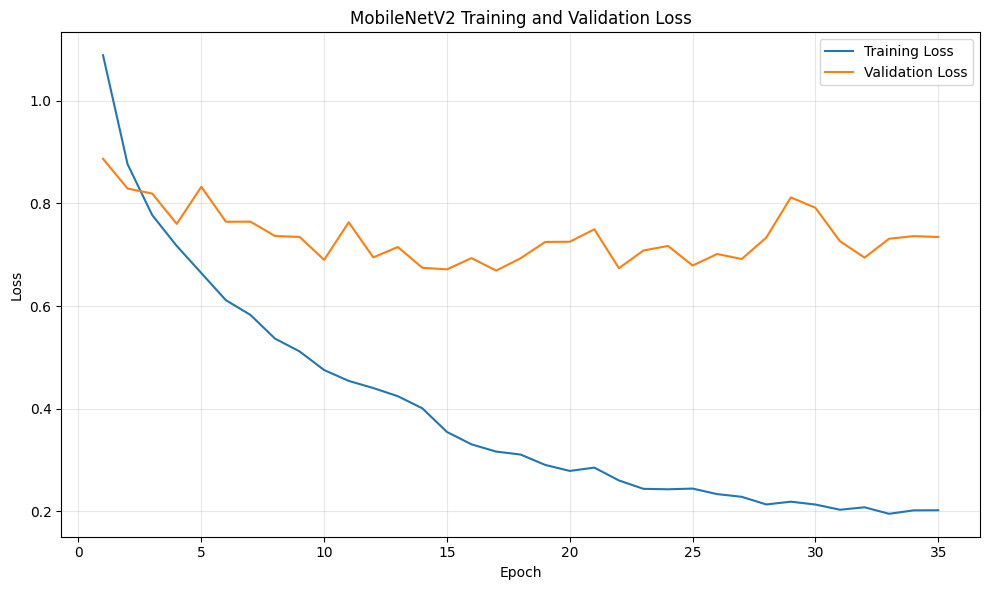

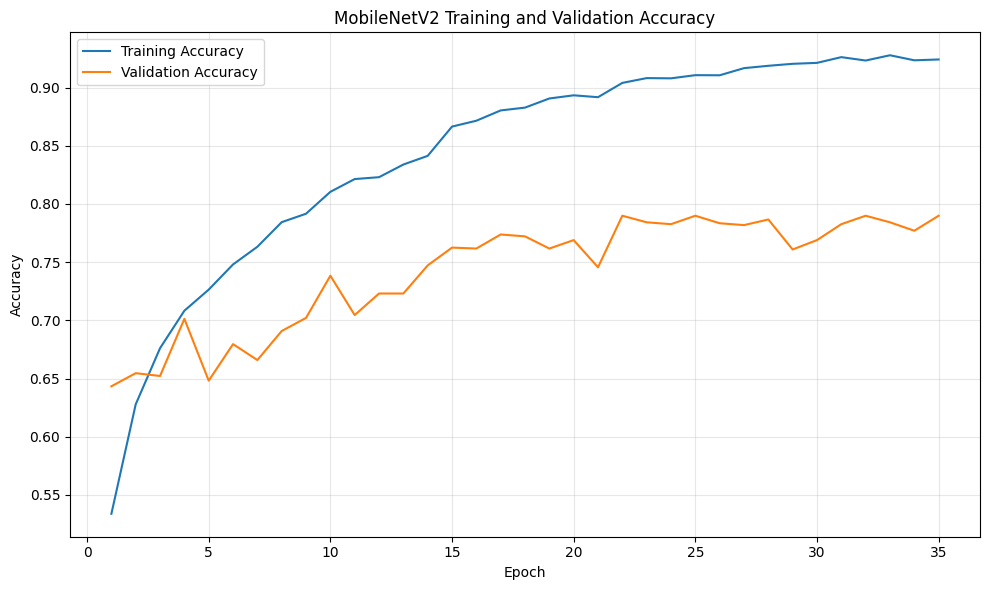

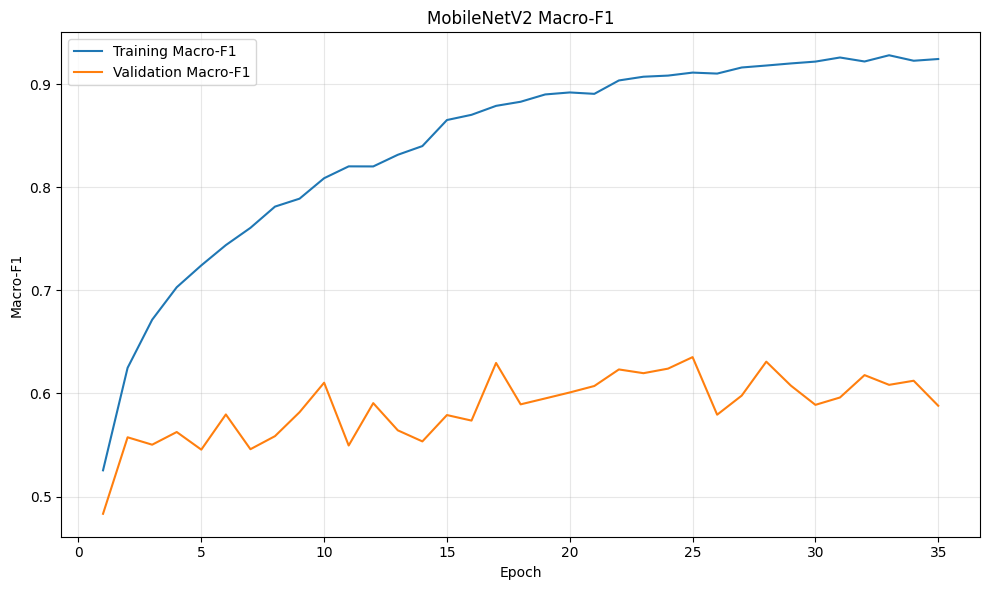

In [22]:
# ============================================================
# CELL 17 — TRAINING CURVES
# ============================================================

history_df = pd.read_csv(
    METRIC_DIR / "training_history.csv"
)

# Loss
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "training_validation_loss.png",
    dpi=300
)

plt.show()


# Accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "training_validation_accuracy.png",
    dpi=300
)

plt.show()


# Macro F1
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_f1_macro"],
    label="Training Macro-F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1_macro"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("MobileNetV2 Macro-F1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "training_validation_macro_f1.png",
    dpi=300
)

plt.show()

In [23]:
# ============================================================
# CELL 18 — LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

model.eval()

print(
    "Loaded best checkpoint from epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation macro-F1:",
    checkpoint["best_metric"]
)

Loaded best checkpoint from epoch: 25
Best validation macro-F1: 0.6352498394257742


In [24]:
# ============================================================
# CELL 19 — FINAL TEST EVALUATION
# ============================================================

test_metrics, y_true, y_pred, y_probs = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print("=" * 80)
print("TEST RESULTS")
print("=" * 80)

for key, value in test_metrics.items():
    print(
        f"{key:25s}: {value:.6f}"
    )

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

TEST RESULTS
accuracy                 : 0.784393
precision_macro          : 0.610133
recall_macro             : 0.633594
f1_macro                 : 0.617573
precision_weighted       : 0.802536
recall_weighted          : 0.784393
f1_weighted              : 0.791594
balanced_accuracy        : 0.633594
kappa                    : 0.656174
mcc                      : 0.657618
loss                     : 0.689786


In [25]:
# ============================================================
# CELL 20 — CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).T

print(report_df)

report_df.to_csv(
    METRIC_DIR / "classification_report.csv"
)

                  precision    recall  f1-score      support
No_DR              0.886548  0.886548  0.886548   617.000000
Mild               0.223301  0.365079  0.277108    63.000000
Moderate           0.795000  0.709821  0.750000   448.000000
Severe             0.363636  0.347826  0.355556    23.000000
Proliferative_DR   0.782178  0.858696  0.818653    92.000000
accuracy           0.784393  0.784393  0.784393     0.784393
macro avg          0.610133  0.633594  0.617573  1243.000000
weighted avg       0.802536  0.784393  0.791594  1243.000000


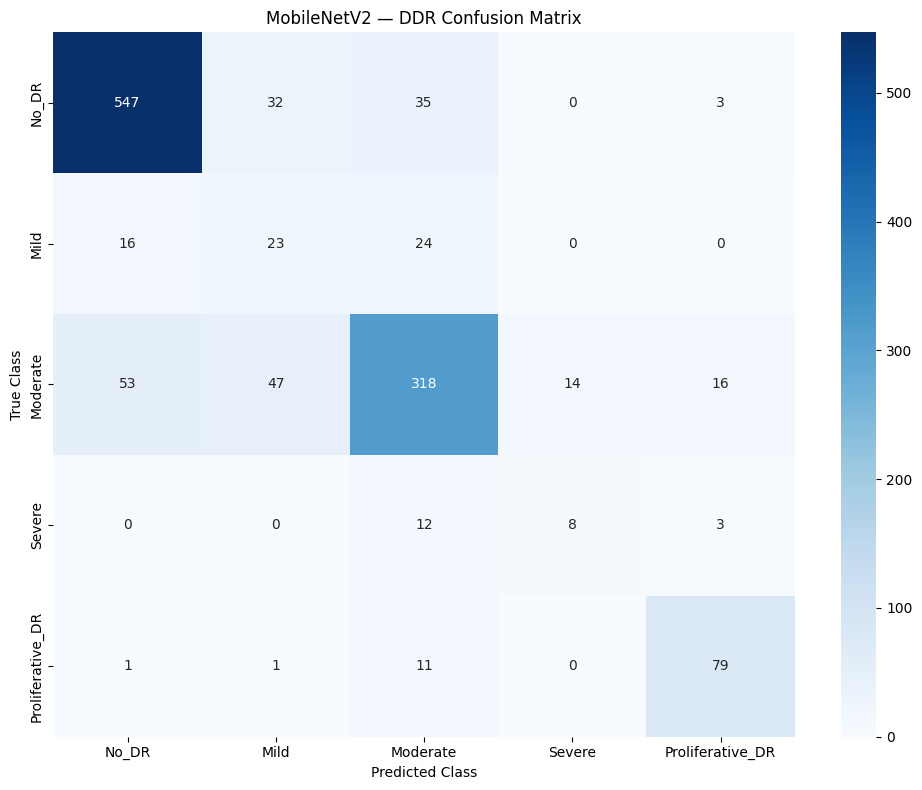

In [26]:
# ============================================================
# CELL 21 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

cm_df.to_csv(
    METRIC_DIR / "confusion_matrix.csv"
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("MobileNetV2 — DDR Confusion Matrix")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

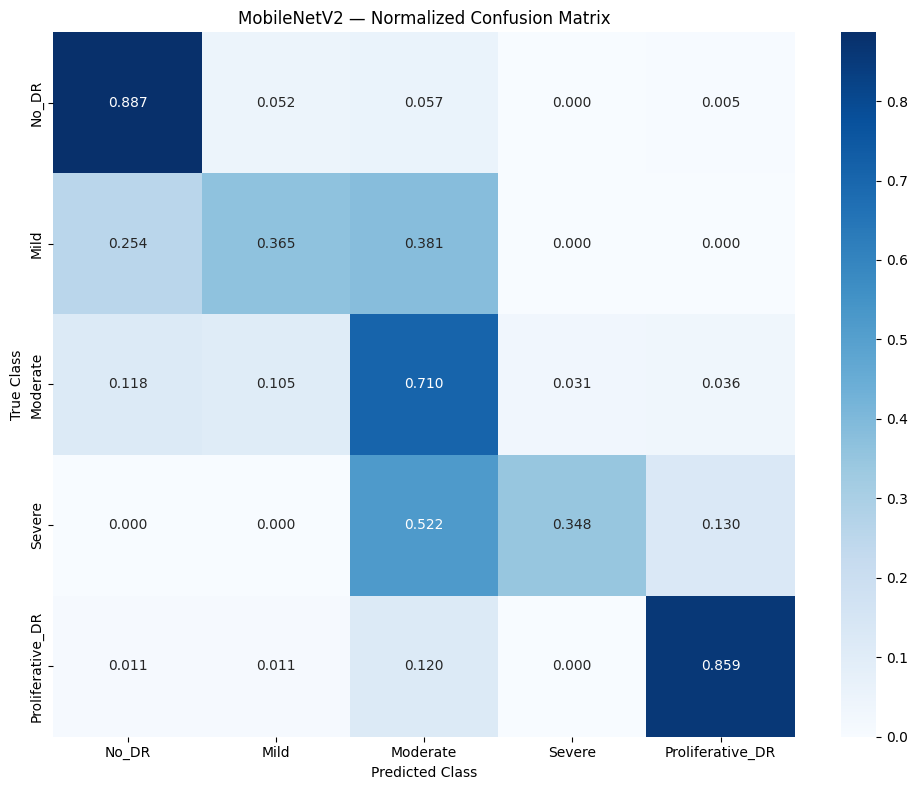

In [27]:
# ============================================================
# CELL 22 — NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = (
    cm.astype(float)
    /
    cm.sum(
        axis=1,
        keepdims=True
    )
)

cm_norm_df = pd.DataFrame(
    cm_normalized,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

cm_norm_df.to_csv(
    METRIC_DIR / "confusion_matrix_normalized.csv"
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(
    "MobileNetV2 — Normalized Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# ============================================================
# CELL 23 — PER-CLASS SENSITIVITY / SPECIFICITY
# ============================================================

specificity_rows = []

for i, class_name in enumerate(CLASS_NAMES):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = (
        cm.sum()
        - TP
        - FN
        - FP
    )

    sensitivity = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    specificity_rows.append({
        "class": class_name,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "sensitivity_recall": sensitivity,
        "specificity": specificity
    })

specificity_df = pd.DataFrame(
    specificity_rows
)

print(specificity_df)

specificity_df.to_csv(
    METRIC_DIR / "sensitivity_specificity.csv",
    index=False
)

              class   TP    TN  FP   FN  sensitivity_recall  specificity
0             No_DR  547   556  70   70            0.886548     0.888179
1              Mild   23  1100  80   40            0.365079     0.932203
2          Moderate  318   713  82  130            0.709821     0.896855
3            Severe    8  1206  14   15            0.347826     0.988525
4  Proliferative_DR   79  1129  22   13            0.858696     0.980886


In [29]:
# ============================================================
# CELL 24 — ROC-AUC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

roc_auc_macro = roc_auc_score(
    y_true_bin,
    y_probs,
    average="macro",
    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(
    y_true_bin,
    y_probs,
    average="weighted",
    multi_class="ovr"
)

print("Macro ROC-AUC   :", roc_auc_macro)
print("Weighted ROC-AUC:", roc_auc_weighted)

auc_rows = []

for i, class_name in enumerate(CLASS_NAMES):

    try:
        class_auc = roc_auc_score(
            y_true_bin[:, i],
            y_probs[:, i]
        )
    except Exception:
        class_auc = np.nan

    auc_rows.append({
        "class": class_name,
        "roc_auc": class_auc
    })

roc_auc_df = pd.DataFrame(
    auc_rows
)

print("\nPer-class ROC-AUC")
print(roc_auc_df)

roc_auc_df.to_csv(
    METRIC_DIR / "roc_auc_per_class.csv",
    index=False
)

Macro ROC-AUC   : 0.9119748390059744
Weighted ROC-AUC: 0.9264015903117044

Per-class ROC-AUC
              class   roc_auc
0             No_DR  0.955326
1              Mild  0.817030
2          Moderate  0.890723
3            Severe  0.912188
4  Proliferative_DR  0.984607


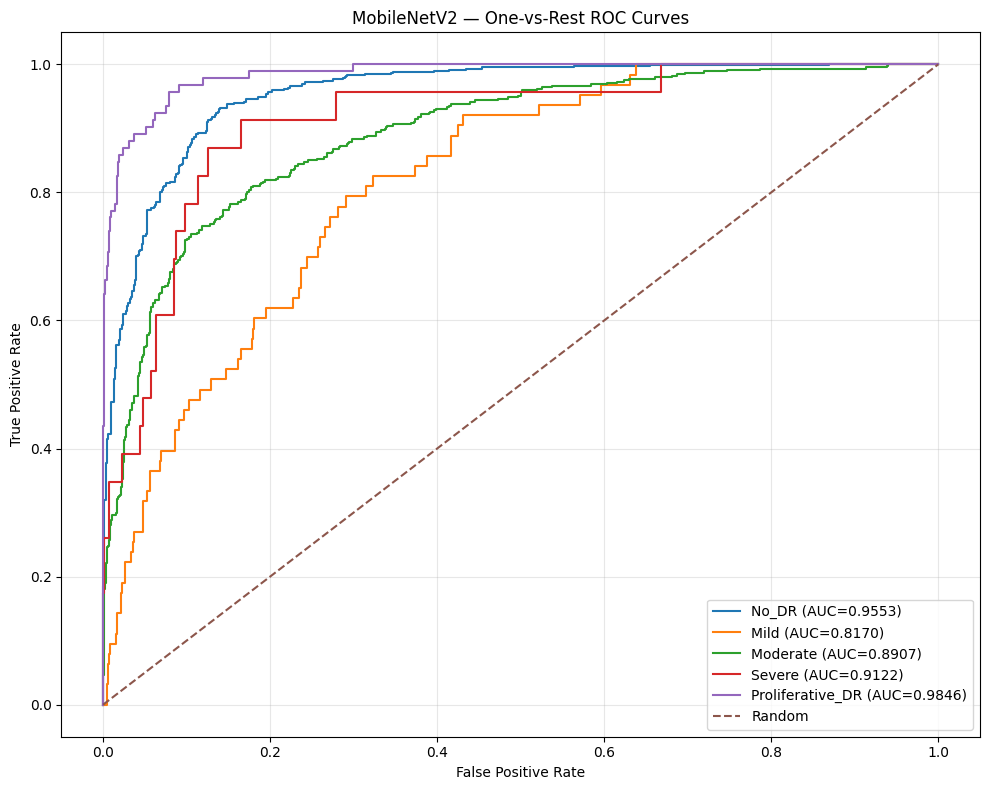

In [30]:
# ============================================================
# CELL 25 — ROC CURVES
# ============================================================

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC={class_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "MobileNetV2 — One-vs-Rest ROC Curves"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "roc_curves.png",
    dpi=300
)

plt.show()

In [31]:
# ============================================================
# CELL 26 — PR-AUC
# ============================================================

pr_rows = []

for i, class_name in enumerate(CLASS_NAMES):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    pr_auc = auc(
        recall,
        precision
    )

    pr_rows.append({
        "class": class_name,
        "pr_auc": pr_auc
    })

pr_auc_df = pd.DataFrame(
    pr_rows
)

print(pr_auc_df)

pr_auc_df.to_csv(
    METRIC_DIR / "pr_auc_per_class.csv",
    index=False
)

macro_pr_auc = pr_auc_df["pr_auc"].mean()

print(
    "\nMacro PR-AUC:",
    macro_pr_auc
)

              class    pr_auc
0             No_DR  0.952288
1              Mild  0.185582
2          Moderate  0.834773
3            Severe  0.367755
4  Proliferative_DR  0.894079

Macro PR-AUC: 0.6468953527387546


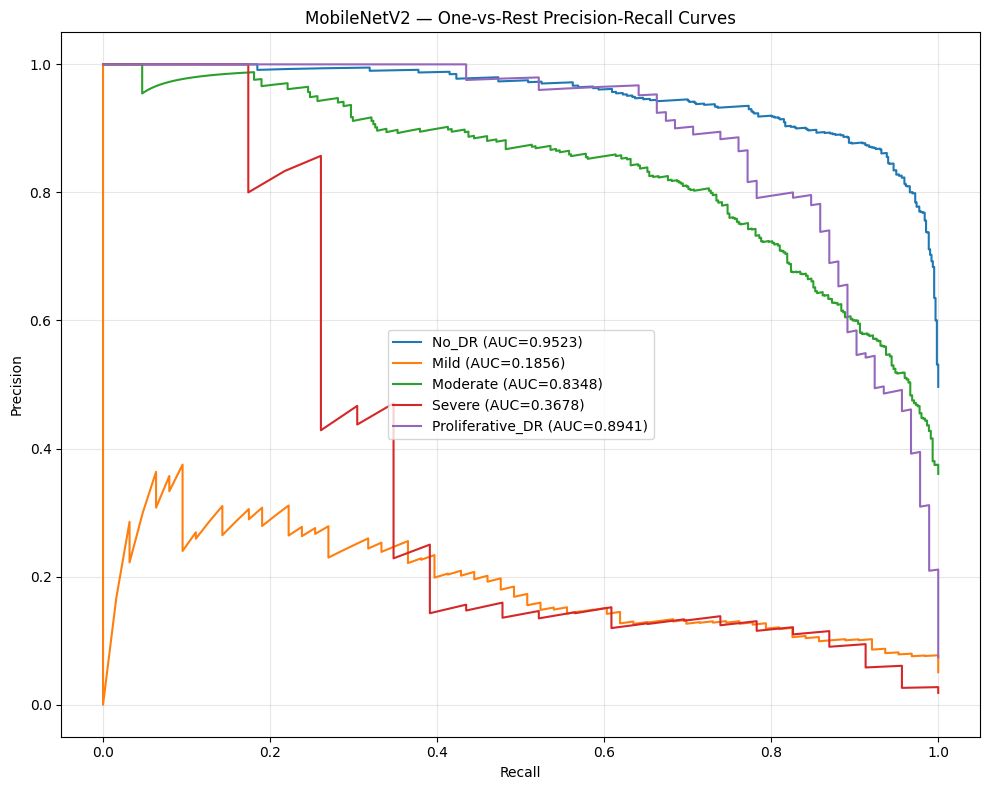

In [32]:
# ============================================================
# CELL 27 — PRECISION-RECALL CURVES
# ============================================================

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(CLASS_NAMES):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    pr_auc = auc(
        recall,
        precision
    )

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AUC={pr_auc:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "MobileNetV2 — One-vs-Rest Precision-Recall Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "precision_recall_curves.png",
    dpi=300
)

plt.show()

In [33]:
# ============================================================
# CELL 28 — LOG LOSS
# ============================================================

test_log_loss = log_loss(
    y_true,
    y_probs,
    labels=list(range(NUM_CLASSES))
)

print(
    "Test Log Loss:",
    test_log_loss
)

Test Log Loss: 0.6897860658655551


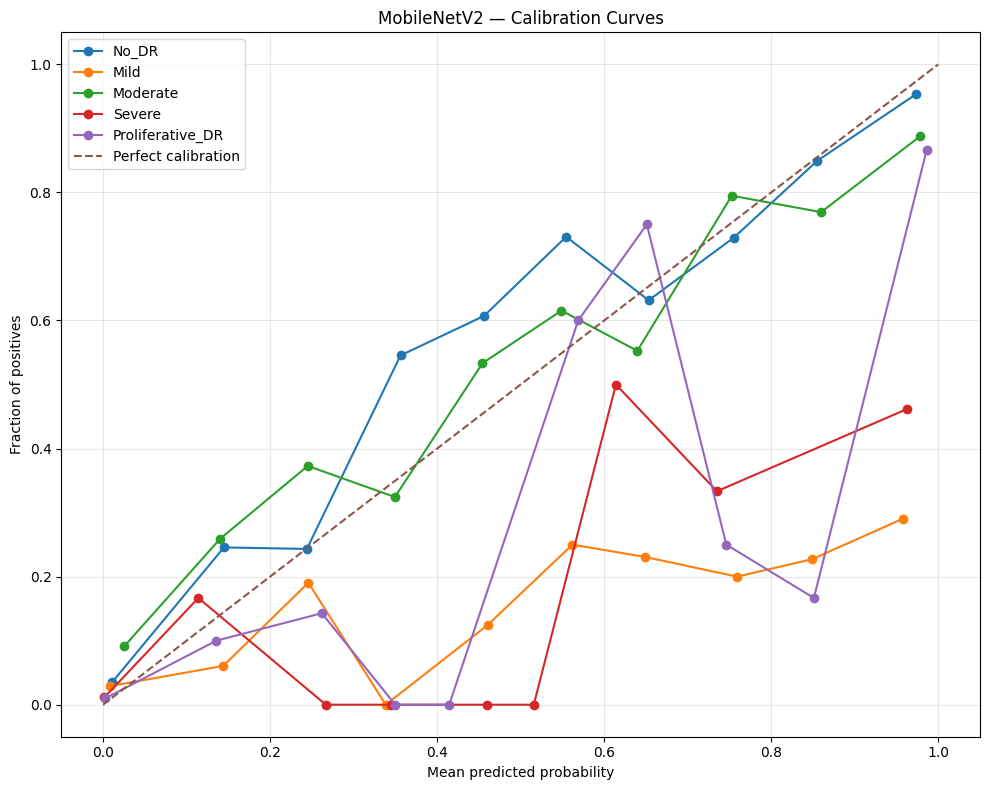

In [34]:
# ============================================================
# CELL 29 — CALIBRATION
# ============================================================

from sklearn.calibration import calibration_curve

plt.figure(
    figsize=(10, 8)
)

for i, class_name in enumerate(CLASS_NAMES):

    true_prob, pred_prob = calibration_curve(
        y_true_bin[:, i],
        y_probs[:, i],
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        pred_prob,
        true_prob,
        marker="o",
        label=class_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")

plt.title(
    "MobileNetV2 — Calibration Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "calibration_curves.png",
    dpi=300
)

plt.show()

In [35]:
# ============================================================
# CELL 30 — BRIER SCORE
# ============================================================

brier_rows = []

for i, class_name in enumerate(CLASS_NAMES):

    score = brier_score_loss(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    brier_rows.append({
        "class": class_name,
        "brier_score": score
    })

brier_df = pd.DataFrame(
    brier_rows
)

print(brier_df)

brier_df.to_csv(
    METRIC_DIR / "brier_scores.csv",
    index=False
)

              class  brier_score
0             No_DR     0.083800
1              Mild     0.072027
2          Moderate     0.130517
3            Severe     0.019870
4  Proliferative_DR     0.024807


In [36]:
# ============================================================
# CELL 31 — BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================

def bootstrap_ci(
    y_true,
    y_pred,
    metric_fn,
    n_bootstrap=2000,
    seed=42
):

    rng = np.random.default_rng(seed)

    n = len(y_true)

    values = []

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        yt = y_true[indices]
        yp = y_pred[indices]

        try:
            value = metric_fn(
                yt,
                yp
            )

            if np.isfinite(value):
                values.append(value)

        except Exception:
            pass

    values = np.array(values)

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    return (
        np.mean(values),
        lower,
        upper
    )


ci_metrics = {

    "accuracy": lambda y, p:
        accuracy_score(y, p),

    "macro_precision": lambda y, p:
        precision_score(
            y,
            p,
            average="macro",
            zero_division=0
        ),

    "macro_recall": lambda y, p:
        recall_score(
            y,
            p,
            average="macro",
            zero_division=0
        ),

    "macro_f1": lambda y, p:
        f1_score(
            y,
            p,
            average="macro",
            zero_division=0
        ),

    "weighted_f1": lambda y, p:
        f1_score(
            y,
            p,
            average="weighted",
            zero_division=0
        ),

    "balanced_accuracy": lambda y, p:
        balanced_accuracy_score(y, p),

    "kappa": lambda y, p:
        cohen_kappa_score(y, p),

    "mcc": lambda y, p:
        matthews_corrcoef(y, p)
}


ci_rows = []

for name, fn in ci_metrics.items():

    mean, lower, upper = bootstrap_ci(
        y_true,
        y_pred,
        fn,
        n_bootstrap=2000,
        seed=SEED
    )

    ci_rows.append({
        "metric": name,
        "estimate": mean,
        "ci_lower_95": lower,
        "ci_upper_95": upper
    })

ci_df = pd.DataFrame(
    ci_rows
)

print(ci_df)

ci_df.to_csv(
    METRIC_DIR / "bootstrap_confidence_intervals.csv",
    index=False
)

              metric  estimate  ci_lower_95  ci_upper_95
0           accuracy  0.784057     0.761866     0.806114
1    macro_precision  0.609313     0.560710     0.658394
2       macro_recall  0.632422     0.584358     0.684855
3           macro_f1  0.615124     0.568856     0.658924
4        weighted_f1  0.791269     0.769342     0.813625
5  balanced_accuracy  0.632422     0.584358     0.684855
6              kappa  0.655436     0.622077     0.688655
7                mcc  0.657056     0.623390     0.689898


In [37]:
# ============================================================
# CELL 32 — FINAL METRICS TABLE
# ============================================================

final_metrics = {

    "Accuracy":
        accuracy_score(y_true, y_pred),

    "Macro Precision":
        precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Macro Recall":
        recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Macro F1":
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Weighted Precision":
        precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Weighted Recall":
        recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Weighted F1":
        f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_true,
            y_pred
        ),

    "Cohen Kappa":
        cohen_kappa_score(
            y_true,
            y_pred
        ),

    "MCC":
        matthews_corrcoef(
            y_true,
            y_pred
        ),

    "Log Loss":
        log_loss(
            y_true,
            y_probs,
            labels=list(range(NUM_CLASSES))
        ),

    "Macro ROC-AUC":
        roc_auc_macro,

    "Weighted ROC-AUC":
        roc_auc_weighted,

    "Macro PR-AUC":
        macro_pr_auc
}

final_metrics_df = pd.DataFrame(
    list(final_metrics.items()),
    columns=[
        "Metric",
        "Value"
    ]
)

print(
    final_metrics_df.to_string(
        index=False
    )
)

final_metrics_df.to_csv(
    METRIC_DIR / "final_metrics.csv",
    index=False
)

            Metric    Value
          Accuracy 0.784393
   Macro Precision 0.610133
      Macro Recall 0.633594
          Macro F1 0.617573
Weighted Precision 0.802536
   Weighted Recall 0.784393
       Weighted F1 0.791594
 Balanced Accuracy 0.633594
       Cohen Kappa 0.656174
               MCC 0.657618
          Log Loss 0.689786
     Macro ROC-AUC 0.911975
  Weighted ROC-AUC 0.926402
      Macro PR-AUC 0.646895


In [38]:
# ============================================================
# CELL 33 — PER-CLASS COMPLETE METRICS
# ============================================================

per_class = []

for i, class_name in enumerate(CLASS_NAMES):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = (
        cm.sum()
        - TP
        - FN
        - FP
    )

    sensitivity = (
        TP / (TP + FN)
        if TP + FN > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP > 0
        else 0
    )

    precision = (
        TP / (TP + FP)
        if TP + FP > 0
        else 0
    )

    f1 = (
        2 * precision * sensitivity /
        (precision + sensitivity)
        if precision + sensitivity > 0
        else 0
    )

    per_class.append({

        "class": class_name,

        "support":
            int(cm[i].sum()),

        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),

        "precision":
            precision,

        "recall_sensitivity":
            sensitivity,

        "specificity":
            specificity,

        "f1":
            f1
    })

per_class_df = pd.DataFrame(
    per_class
)

print(per_class_df)

per_class_df.to_csv(
    METRIC_DIR / "per_class_complete_metrics.csv",
    index=False
)

              class  support   TP    TN  FP   FN  precision  \
0             No_DR      617  547   556  70   70   0.886548   
1              Mild       63   23  1100  80   40   0.223301   
2          Moderate      448  318   713  82  130   0.795000   
3            Severe       23    8  1206  14   15   0.363636   
4  Proliferative_DR       92   79  1129  22   13   0.782178   

   recall_sensitivity  specificity        f1  
0            0.886548     0.888179  0.886548  
1            0.365079     0.932203  0.277108  
2            0.709821     0.896855  0.750000  
3            0.347826     0.988525  0.355556  
4            0.858696     0.980886  0.818653  


In [39]:
# ============================================================
# CELL 34 — SAVE TEST PREDICTIONS
# ============================================================

test_paths = [
    path
    for path, label in test_dataset.samples
]

predictions_df = pd.DataFrame({

    "path":
        test_paths,

    "true_label":
        y_true,

    "true_class":
        [
            CLASS_NAMES[x]
            for x in y_true
        ],

    "predicted_label":
        y_pred,

    "predicted_class":
        [
            CLASS_NAMES[x]
            for x in y_pred
        ],

    "confidence":
        np.max(
            y_probs,
            axis=1
        )
})

for i, class_name in enumerate(CLASS_NAMES):

    predictions_df[
        f"prob_{class_name}"
    ] = y_probs[:, i]

predictions_df.to_csv(
    METRIC_DIR / "test_predictions.csv",
    index=False
)

print(
    "Saved:",
    METRIC_DIR / "test_predictions.csv"
)

Saved: /kaggle/working/mobilenetv2_ddr_results/metrics/test_predictions.csv


In [40]:
# ============================================================
# CELL 35 — MISCLASSIFICATION SUMMARY
# ============================================================

misclassified = (
    predictions_df[
        predictions_df.true_label
        != predictions_df.predicted_label
    ]
    .copy()
)

misclassified.to_csv(
    METRIC_DIR / "misclassified_images.csv",
    index=False
)

print(
    "Total test images:",
    len(predictions_df)
)

print(
    "Correct:",
    (predictions_df.true_label ==
     predictions_df.predicted_label).sum()
)

print(
    "Misclassified:",
    len(misclassified)
)

print("\nMost common error pairs:")

error_pairs = (
    misclassified
    .groupby(
        [
            "true_class",
            "predicted_class"
        ]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print(error_pairs)

Total test images: 1243
Correct: 975
Misclassified: 268

Most common error pairs:
true_class        predicted_class 
Moderate          No_DR               53
                  Mild                47
No_DR             Moderate            35
                  Mild                32
Mild              Moderate            24
                  No_DR               16
Moderate          Proliferative_DR    16
                  Severe              14
Severe            Moderate            12
Proliferative_DR  Moderate            11
Severe            Proliferative_DR     3
No_DR             Proliferative_DR     3
Proliferative_DR  Mild                 1
                  No_DR                1
dtype: int64


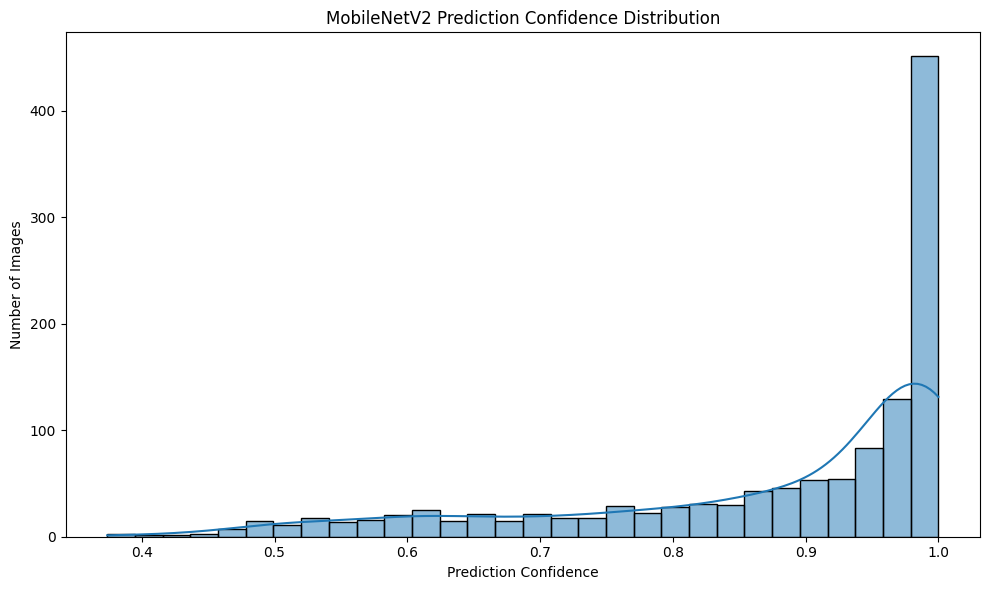

In [41]:
# ============================================================
# CELL 36 — PREDICTION CONFIDENCE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    predictions_df["confidence"],
    bins=30,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")

plt.title(
    "MobileNetV2 Prediction Confidence Distribution"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "prediction_confidence.png",
    dpi=300
)

plt.show()

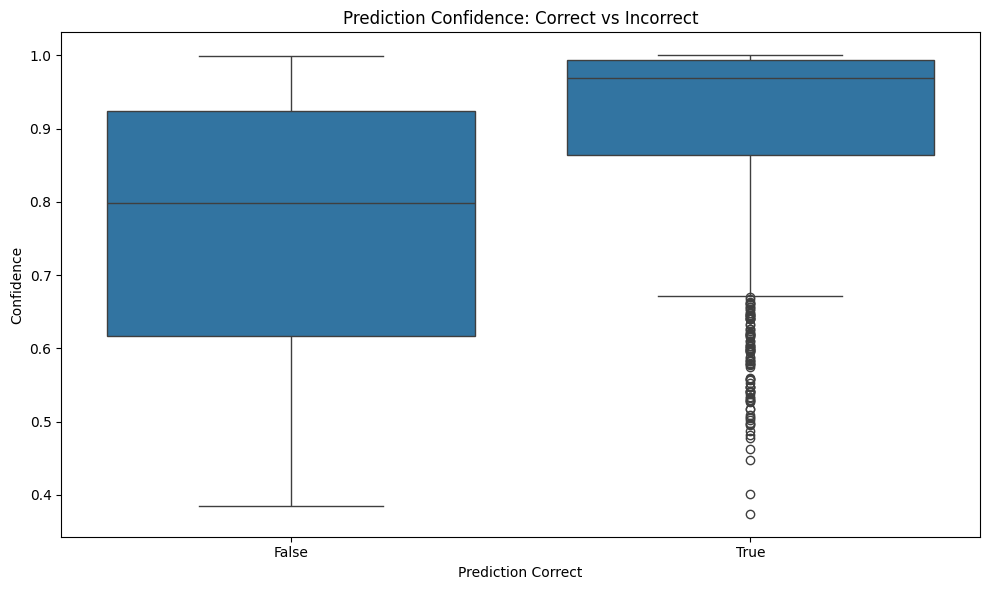

In [42]:
# ============================================================
# CELL 37 — CONFIDENCE: CORRECT VS INCORRECT
# ============================================================

predictions_df["correct"] = (
    predictions_df["true_label"]
    ==
    predictions_df["predicted_label"]
)

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=predictions_df,
    x="correct",
    y="confidence"
)

plt.xlabel("Prediction Correct")
plt.ylabel("Confidence")

plt.title(
    "Prediction Confidence: Correct vs Incorrect"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "confidence_correct_vs_incorrect.png",
    dpi=300
)

plt.show()

In [43]:
# ============================================================
# CELL 38 — GRAD-CAM CLASS
# ============================================================

class GradCAM:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self.save_activation
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self.save_gradient
            )
        )

    def save_activation(
        self,
        module,
        input,
        output
    ):

        self.activations = output

    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]

    def generate(
        self,
        image,
        class_index=None
    ):

        self.model.zero_grad(
            set_to_none=True
        )

        output = self.model(
            image
        )

        if class_index is None:

            class_index = (
                output.argmax(
                    dim=1
                ).item()
            )

        score = output[
            0,
            class_index
        ]

        score.backward()

        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights * activations
        ).sum(
            dim=1,
            keepdim=True
        )

        cam = torch.relu(
            cam
        )

        cam = torch.nn.functional.interpolate(
            cam,
            size=(
                IMAGE_SIZE,
                IMAGE_SIZE
            ),
            mode="bilinear",
            align_corners=False
        )

        cam = cam[
            0,
            0
        ]

        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        return (
            cam.detach().cpu().numpy(),
            class_index
        )

    def remove_hooks(self):

        self.forward_handle.remove()
        self.backward_handle.remove()

In [44]:
# ============================================================
# CELL 39 — GRAD-CAM VISUALIZATION
# ============================================================

def denormalize_image(tensor):

    image = tensor.detach().cpu()

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    image = (
        image * std + mean
    )

    image = torch.clamp(
        image,
        0,
        1
    )

    return image.permute(
        1, 2, 0
    ).numpy()


def overlay_gradcam(
    image,
    cam,
    alpha=0.45
):

    import matplotlib.cm as cm

    heatmap = cm.jet(
        cam
    )[:, :, :3]

    overlay = (
        (1 - alpha) * image
        +
        alpha * heatmap
    )

    return np.clip(
        overlay,
        0,
        1
    )

In [45]:
# ============================================================
# CELL 40 — GENERATE GRAD-CAM
# ============================================================

# Final convolutional feature layer
target_layer = model.features[-1]

gradcam = GradCAM(
    model,
    target_layer
)

# Select examples from test set
num_gradcam_images = 20

indices = np.linspace(
    0,
    len(test_dataset) - 1,
    num_gradcam_images,
    dtype=int
)

model.eval()

for idx in indices:

    image, true_label = test_dataset[idx]

    input_tensor = (
        image
        .unsqueeze(0)
        .to(DEVICE)
    )

    cam, predicted_class = (
        gradcam.generate(
            input_tensor
        )
    )

    original = denormalize_image(
        image
    )

    overlay = overlay_gradcam(
        original,
        cam
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        original
    )

    axes[0].set_title(
        f"Original\n"
        f"True: {CLASS_NAMES[true_label]}"
    )

    axes[0].axis("off")

    axes[1].imshow(
        cam,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM"
    )

    axes[1].axis("off")

    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        f"Prediction: "
        f"{CLASS_NAMES[predicted_class]}"
    )

    axes[2].axis("off")

    plt.tight_layout()

    plt.savefig(
        GRADCAM_DIR /
        f"gradcam_{idx:05d}.png",
        dpi=250,
        bbox_inches="tight"
    )

    plt.close()

gradcam.remove_hooks()

print(
    "Grad-CAM results saved to:",
    GRADCAM_DIR
)

Grad-CAM results saved to: /kaggle/working/mobilenetv2_ddr_results/gradcam


In [46]:
# ============================================================
# CELL 41 — GRAD-CAM FOR MISCLASSIFIED IMAGES
# ============================================================

target_layer = model.features[-1]

gradcam = GradCAM(
    model,
    target_layer
)

error_indices = []

for idx in range(
    len(test_dataset)
):

    if (
        y_true[idx]
        !=
        y_pred[idx]
    ):

        error_indices.append(idx)

    if len(error_indices) >= 20:
        break


for idx in error_indices:

    image, true_label = test_dataset[idx]

    input_tensor = (
        image
        .unsqueeze(0)
        .to(DEVICE)
    )

    cam, predicted_class = (
        gradcam.generate(
            input_tensor
        )
    )

    original = denormalize_image(
        image
    )

    overlay = overlay_gradcam(
        original,
        cam
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(original)

    axes[0].set_title(
        f"True: "
        f"{CLASS_NAMES[true_label]}"
    )

    axes[0].axis("off")

    axes[1].imshow(
        cam,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM"
    )

    axes[1].axis("off")

    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        f"Predicted: "
        f"{CLASS_NAMES[predicted_class]}"
    )

    axes[2].axis("off")

    plt.tight_layout()

    plt.savefig(
        GRADCAM_DIR /
        f"error_gradcam_{idx:05d}.png",
        dpi=250,
        bbox_inches="tight"
    )

    plt.close()

gradcam.remove_hooks()

print(
    "Misclassified Grad-CAM images generated:",
    len(error_indices)
)

Misclassified Grad-CAM images generated: 20


In [47]:
# ============================================================
# CELL 42 — SAVE EXPERIMENT CONFIGURATION
# ============================================================

config = {

    "model":
        "MobileNetV2",

    "pretrained":
        "ImageNet IMAGENET1K_V2",

    "dataset":
        "DDR",

    "dataset_root":
        str(DDR_ROOT),

    "train_images":
        len(train_dataset),

    "validation_images":
        len(val_dataset),

    "test_images":
        len(test_dataset),

    "classes":
        CLASS_NAMES,

    "num_classes":
        NUM_CLASSES,

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "optimizer":
        OPTIMIZER_NAME,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "oversampling":
        USE_OVERSAMPLING,

    "scheduler":
        SCHEDULER_NAME
        if USE_SCHEDULER
        else None,

    "checkpoint_metric":
        CHECKPOINT_METRIC,

    "seed":
        SEED,

    "device":
        str(DEVICE),

    "training_time_hours":
        training_time / 3600
}

with open(
    METRIC_DIR / "experiment_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print(
    "Configuration saved."
)

Configuration saved.


In [48]:
# ============================================================
# CELL 43 — FINAL RESULTS SUMMARY
# ============================================================

summary = {
    "Model": "MobileNetV2",
    "Dataset": "DDR",
    "Train Images": len(train_dataset),
    "Validation Images": len(val_dataset),
    "Test Images": len(test_dataset),
    "Best Epoch": best_epoch,
    "Best Validation Macro-F1": best_metric,

    **final_metrics
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=[
        "Metric",
        "Value"
    ]
)

summary_df.to_csv(
    OUTPUT_ROOT / "FINAL_RESULTS.csv",
    index=False
)

print(
    summary_df.to_string(
        index=False
    )
)

                  Metric       Value
                   Model MobileNetV2
                 Dataset         DDR
            Train Images        9937
       Validation Images        1242
             Test Images        1243
              Best Epoch          25
Best Validation Macro-F1     0.63525
                Accuracy    0.784393
         Macro Precision    0.610133
            Macro Recall    0.633594
                Macro F1    0.617573
      Weighted Precision    0.802536
         Weighted Recall    0.784393
             Weighted F1    0.791594
       Balanced Accuracy    0.633594
             Cohen Kappa    0.656174
                     MCC    0.657618
                Log Loss    0.689786
           Macro ROC-AUC    0.911975
        Weighted ROC-AUC    0.926402
            Macro PR-AUC    0.646895


In [49]:
# ============================================================
# CELL 44 — RESULTS DIRECTORY
# ============================================================

print("=" * 80)
print("GENERATED RESULTS")
print("=" * 80)

for root, dirs, files in os.walk(
    OUTPUT_ROOT
):

    level = (
        Path(root)
        .relative_to(OUTPUT_ROOT)
        .parts
    )

    indent = "  " * len(level)

    print(
        f"\n{indent}{Path(root).name}/"
    )

    for file in sorted(files):

        print(
            f"{indent}  {file}"
        )

GENERATED RESULTS

mobilenetv2_ddr_results/
  FINAL_RESULTS.csv

  plots/
    calibration_curves.png
    confidence_correct_vs_incorrect.png
    confusion_matrix.png
    confusion_matrix_normalized.png
    dataset_class_distribution.png
    precision_recall_curves.png
    prediction_confidence.png
    roc_curves.png
    training_samples.png
    training_validation_accuracy.png
    training_validation_loss.png
    training_validation_macro_f1.png

  metrics/
    bootstrap_confidence_intervals.csv
    brier_scores.csv
    classification_report.csv
    confusion_matrix.csv
    confusion_matrix_normalized.csv
    experiment_config.json
    final_metrics.csv
    misclassified_images.csv
    per_class_complete_metrics.csv
    pr_auc_per_class.csv
    roc_auc_per_class.csv
    sensitivity_specificity.csv
    test_predictions.csv
    training_history.csv

  checkpoints/
    mobilenetv2_ddr_best.pth

  gradcam/
    error_gradcam_00001.png
    error_gradcam_00002.png
    error_gradcam_00014.png
